# Step 4: Model Implementation & Comparison
**Capstone Project — Cybersecurity: Detect Anomalies in Network Traffic**

Dataset: CICIDS2017  
This notebook covers:
1. Load preprocessed data from Step 3
2. Train/test split (stratified)
3. Binary classification — Logistic Regression, Random Forest, XGBoost
4. Hyperparameter tuning — Random Forest and XGBoost (RandomizedSearchCV)
5. Multiclass classification — same three model families on attack categories
6. Evaluation — accuracy, precision, recall, F1, AUC-ROC, confusion matrices
7. Model comparison table
8. Save models and configs for reproducibility

## 1. Setup & Imports

In [1]:
!pip install xgboost scikit-learn joblib matplotlib seaborn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform

from google.colab import drive
drive.mount('/content/drive')

BASE = '/content/drive/MyDrive/capstone/models/'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

os.makedirs('./models', exist_ok=True)

for fname in ['X_selected.npy', 'y_binary.npy', 'y_multiclass.npy',
              'selected_features.csv', 'robust_scaler.pkl', 'pca_95.pkl',
              'y_category_labels.pkl']:
    src = BASE + fname
    dst = './models/' + fname
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'Copied: {fname}')
    else:
        print(f'Not found: {fname}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print('Imports complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied: X_selected.npy
Copied: y_binary.npy
Copied: y_multiclass.npy
Copied: selected_features.csv
Copied: robust_scaler.pkl
Copied: pca_95.pkl
Copied: y_category_labels.pkl
Imports complete.


## 2. Load Preprocessed Data

We load the artefacts saved at the end of Step 3:
- `X_selected.npy` — feature matrix (40 SHAP-selected features, RobustScaled, log-transformed)
- `y_binary.npy` — binary target (0 = Benign, 1 = Attack)
- `y_multiclass.npy` — encoded attack category labels
- `selected_features.csv` — feature names for interpretability

In [3]:
# ── Kaggle API setup (if needed to re-run Step 3 data first) ─────────────────
# If you have already run Step 3 and have models/ saved, skip this block.
import json as _json

if not os.path.exists('./models/X_selected.npy'):
    print('Data not found in ./models/ — please run Step 3 notebook first.')
    print('Or mount your Drive if artefacts are stored there.')
else:
    X = np.load('./models/X_selected.npy')
    y_bin = np.load('./models/y_binary.npy')
    y_multi = np.load('./models/y_multiclass.npy')

    feature_names = pd.read_csv('./models/selected_features.csv')['feature'].tolist()
    category_labels = joblib.load('./models/y_category_labels.pkl')
    unique_categories = sorted(set(category_labels))

    print(f'X shape          : {X.shape}')
    print(f'y_binary counts  : {dict(zip(*np.unique(y_bin, return_counts=True)))}')
    print(f'Attack categories: {unique_categories}')
    print(f'y_multi counts   : {dict(zip(*np.unique(y_multi, return_counts=True)))}')

X shape          : (467589, 40)
y_binary counts  : {np.int8(0): np.int64(383649), np.int8(1): np.int64(83940)}
Attack categories: ['Benign', 'Botnet', 'Brute Force', 'DDoS', 'DoS', 'Infiltration', 'Other', 'Probe']
y_multi counts   : {np.int64(0): np.int64(383649), np.int64(1): np.int64(342), np.int64(2): np.int64(1799), np.int64(3): np.int64(22612), np.int64(4): np.int64(34752), np.int64(5): np.int64(6), np.int64(6): np.int64(380), np.int64(7): np.int64(24049)}


## 3. Train / Test Split

Stratified 80/20 split on the binary label to preserve the class imbalance ratio across both sets.

In [4]:
X_train, X_test, y_train_bin, y_test_bin, y_train_multi, y_test_multi = train_test_split(
    X, y_bin, y_multi,
    test_size=0.20,
    stratify=y_bin,
    random_state=RANDOM_SEED
)

print(f'Train : {X_train.shape[0]:,} rows')
print(f'Test  : {X_test.shape[0]:,} rows')
print(f'Train class balance (binary): {dict(zip(*np.unique(y_train_bin, return_counts=True)))}')
print(f'Test  class balance (binary): {dict(zip(*np.unique(y_test_bin, return_counts=True)))}')

Train : 374,071 rows
Test  : 93,518 rows
Train class balance (binary): {np.int8(0): np.int64(306919), np.int8(1): np.int64(67152)}
Test  class balance (binary): {np.int8(0): np.int64(76730), np.int8(1): np.int64(16788)}


## 4. Helper: Evaluation Function

A single function to compute and display all required metrics for both binary and multiclass tasks.

In [16]:
def evaluate_model(model, X_test, y_test, task='binary', model_name='Model', label_names=None):
    """
    Compute and display evaluation metrics.
    Returns a dict of key scalar metrics for the summary table.
    """
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary' if task == 'binary' else 'weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='binary' if task == 'binary' else 'weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='binary' if task == 'binary' else 'weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # AUC-ROC
    # --- FIXED AUC-ROC LOGIC ---
    auc = np.nan  # Initialize to avoid UnboundLocalError
    if hasattr(model, 'predict_proba'):
        try:
            y_prob = model.predict_proba(X_test)

            if task == 'binary':
                # Handle binary calculation entirely within this block
                auc = roc_auc_score(y_test, y_prob[:, 1])

            elif task == 'multiclass':
                # Handle multiclass calculation entirely within this block
                classes_in_test = np.unique(y_test)
                col_indices = [np.where(model.classes_ == c)[0][0] for c in classes_in_test]
                y_prob_filtered = y_prob[:, col_indices]

                auc = roc_auc_score(y_test, y_prob_filtered, multi_class='ovr',
                                    average='weighted', labels=classes_in_test)
        except Exception:
            auc = np.nan

    print(f'\n=== {model_name} ({task}) ===')
    print(f'Accuracy        : {acc:.4f}')
    print(f'Precision (wtd) : {prec:.4f}')
    print(f'Recall (wtd)    : {rec:.4f}')
    print(f'F1 (weighted)   : {f1:.4f}')
    print(f'F1 (macro)      : {f1_macro:.4f}')
    print(f'AUC-ROC         : {auc:.4f}' if not np.isnan(auc) else 'AUC-ROC         : N/A')
    print()
    present_labels = np.unique(y_test)
    filtered_names = [label_names[i] for i in present_labels] if label_names else None
    print(classification_report(y_test, y_pred, labels=present_labels,
                                target_names=filtered_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(max(6, len(np.unique(y_test))), max(5, len(np.unique(y_test)))))
    present_labels = np.unique(np.concatenate([y_test, y_pred]))
    filtered_names = [label_names[i] for i in present_labels] if label_names else None
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=filtered_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation='vertical')
    ax.set_title(f'{model_name} — Confusion Matrix ({task})', fontsize=11)
    plt.tight_layout()
    fname = f'cm_{model_name.lower().replace(" ", "_")}_{task}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'Model': model_name, 'Task': task,
        'Accuracy': round(acc, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4), 'F1 (weighted)': round(f1, 4),
        'F1 (macro)': round(f1_macro, 4),
        'AUC-ROC': round(auc, 4) if not np.isnan(auc) else 'N/A'
    }

print('evaluate_model() ready.')

evaluate_model() ready.


## 5. Binary Classification

**Target**: 0 = Benign, 1 = Attack

CICIDS2017 is heavily imbalanced (~80% benign, ~20% attack in the stratified sample). All models use `class_weight='balanced'` or equivalent to prevent the classifier from simply predicting the majority class.

Models trained:
1. Logistic Regression (L2 regularisation, `liblinear` solver)
2. Random Forest (baseline, then tuned)
3. XGBoost (baseline, then tuned)

### 5.1 Logistic Regression

Logistic Regression (binary) — trained.

=== Logistic Regression (binary) ===
Accuracy        : 0.8559
Precision (wtd) : 0.5658
Recall (wtd)    : 0.8491
F1 (weighted)   : 0.6791
F1 (macro)      : 0.7931
AUC-ROC         : 0.9271

              precision    recall  f1-score   support

      Benign       0.96      0.86      0.91     76730
      Attack       0.57      0.85      0.68     16788

    accuracy                           0.86     93518
   macro avg       0.76      0.85      0.79     93518
weighted avg       0.89      0.86      0.87     93518



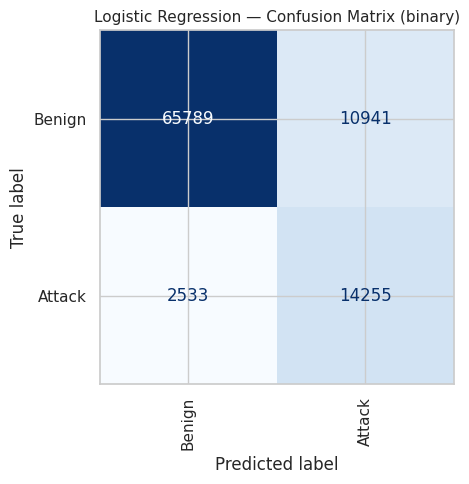

In [6]:
lr_bin = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs',
    class_weight='balanced', max_iter=1000,
    random_state=RANDOM_SEED, n_jobs=-1
)
lr_bin.fit(X_train, y_train_bin)
print('Logistic Regression (binary) — trained.')

result_lr_bin = evaluate_model(
    lr_bin, X_test, y_test_bin,
    task='binary', model_name='Logistic Regression',
    label_names=['Benign', 'Attack']
)

### 5.2 Random Forest — Baseline

Random Forest Baseline (binary) — trained.

=== RF Baseline (binary) ===
Accuracy        : 0.9988
Precision (wtd) : 0.9954
Recall (wtd)    : 0.9982
F1 (weighted)   : 0.9968
F1 (macro)      : 0.9980
AUC-ROC         : 0.9999

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     76730
      Attack       1.00      1.00      1.00     16788

    accuracy                           1.00     93518
   macro avg       1.00      1.00      1.00     93518
weighted avg       1.00      1.00      1.00     93518



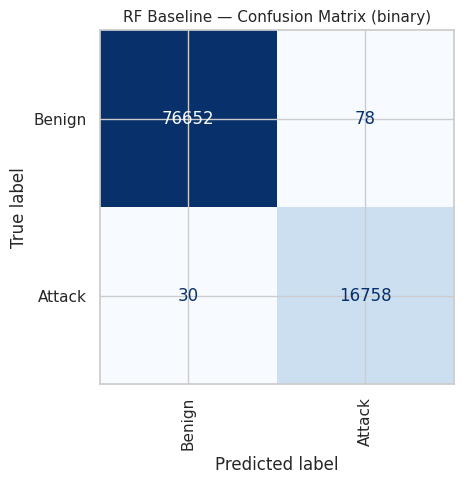

In [7]:
rf_bin_base = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_leaf=2,
    class_weight='balanced', n_jobs=-1,
    random_state=RANDOM_SEED
)
rf_bin_base.fit(X_train, y_train_bin)
print('Random Forest Baseline (binary) — trained.')

result_rf_bin_base = evaluate_model(
    rf_bin_base, X_test, y_test_bin,
    task='binary', model_name='RF Baseline',
    label_names=['Benign', 'Attack']
)

### 5.3 Random Forest — Hyperparameter Tuning (RandomizedSearchCV)

We search over a defined hyperparameter space using 3-fold stratified cross-validation. Optimising for **F1 (weighted)** to balance precision and recall under class imbalance.

In [8]:
rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': randint(1, 5),
    'min_samples_split': randint(2, 6),
    'max_features': ['sqrt', 'log2'],
}

cv_binary = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

# Subsample to 30% for tuning only — refit on full train set after
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train_bin,
    train_size=0.30,
    stratify=y_train_bin,
    random_state=RANDOM_SEED
)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', bootstrap=True,
                           n_jobs=-1, random_state=RANDOM_SEED),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=cv_binary,
    n_jobs=1,          # avoid parallelism conflict with RF's own n_jobs=-1
    random_state=RANDOM_SEED,
    verbose=1
)
rf_search.fit(X_tune, y_tune)

print(f'Best RF params   : {rf_search.best_params_}')
print(f'Best CV F1       : {rf_search.best_score_:.4f}')

# Refit best estimator on full training data
rf_bin_tuned = RandomForestClassifier(
    **rf_search.best_params_,
    class_weight='balanced', bootstrap=True,
    n_jobs=-1, random_state=RANDOM_SEED
)
rf_bin_tuned.fit(X_train, y_train_bin)
print('Refitted on full training set.')

with open('./models/rf_binary_best_params.json', 'w') as f:
    json.dump(rf_search.best_params_, f, indent=2)
print('Saved: ./models/rf_binary_best_params.json')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF params   : {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 200}
Best CV F1       : 0.9980
Refitted on full training set.
Saved: ./models/rf_binary_best_params.json



=== RF Tuned (binary) ===
Accuracy        : 0.9989
Precision (wtd) : 0.9957
Recall (wtd)    : 0.9983
F1 (weighted)   : 0.9970
F1 (macro)      : 0.9982
AUC-ROC         : 0.9999

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     76730
      Attack       1.00      1.00      1.00     16788

    accuracy                           1.00     93518
   macro avg       1.00      1.00      1.00     93518
weighted avg       1.00      1.00      1.00     93518



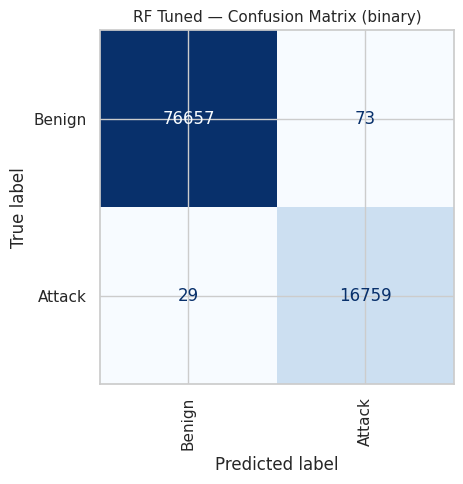

In [9]:
result_rf_bin_tuned = evaluate_model(
    rf_bin_tuned, X_test, y_test_bin,
    task='binary', model_name='RF Tuned',
    label_names=['Benign', 'Attack']
)

### 5.4 XGBoost — Baseline

scale_pos_weight = 4.57  (neg=306,919, pos=67,152)
XGBoost Baseline (binary) — trained.

=== XGBoost Baseline (binary) ===
Accuracy        : 0.9990
Precision (wtd) : 0.9948
Recall (wtd)    : 0.9995
F1 (weighted)   : 0.9972
F1 (macro)      : 0.9983
AUC-ROC         : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     76730
      Attack       0.99      1.00      1.00     16788

    accuracy                           1.00     93518
   macro avg       1.00      1.00      1.00     93518
weighted avg       1.00      1.00      1.00     93518



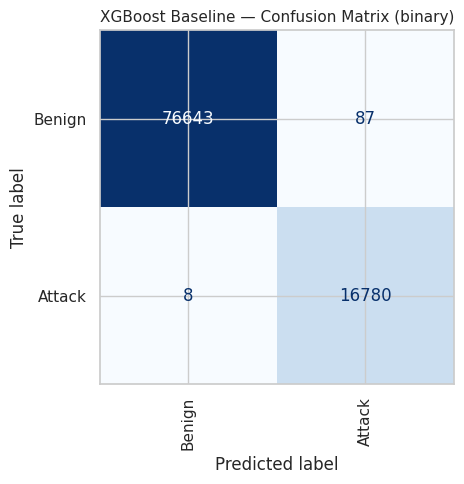

In [10]:
# scale_pos_weight compensates for class imbalance:
# set to count(negative) / count(positive)
n_neg = (y_train_bin == 0).sum()
n_pos = (y_train_bin == 1).sum()
scale_pos = n_neg / n_pos
print(f'scale_pos_weight = {scale_pos:.2f}  (neg={n_neg:,}, pos={n_pos:,})')

xgb_bin_base = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    device='cuda',
    tree_method='hist',
    random_state=RANDOM_SEED, n_jobs=-1,
    use_label_encoder=False
)
xgb_bin_base.fit(X_train, y_train_bin)
print('XGBoost Baseline (binary) — trained.')

result_xgb_bin_base = evaluate_model(
    xgb_bin_base, X_test, y_test_bin,
    task='binary', model_name='XGBoost Baseline',
    label_names=['Benign', 'Attack']
)

### 5.5 XGBoost — Hyperparameter Tuning

In [11]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.05, 0.25),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 6),
    'gamma': uniform(0, 0.3),
    'reg_alpha': uniform(0, 0.5),
    'reg_lambda': uniform(0.5, 1.5)
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        device='cuda',
        tree_method='hist',
        random_state=RANDOM_SEED,
        n_jobs=-1,
        use_label_encoder=False
    ),
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=cv_binary,
    n_jobs=1,          # same reason as RF — avoid nested parallelism
    random_state=RANDOM_SEED,
    verbose=1
)
xgb_search.fit(X_tune, y_tune)   # reuse the 30% subsample from RF tuning

print(f'Best XGBoost params : {xgb_search.best_params_}')
print(f'Best CV F1          : {xgb_search.best_score_:.4f}')

# Refit on full training data
xgb_bin_tuned = XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    device='cuda',
    tree_method='hist',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    use_label_encoder=False
)
xgb_bin_tuned.fit(X_train, y_train_bin)
print('Refitted on full training set.')

with open('./models/xgb_binary_best_params.json', 'w') as f:
    json.dump(xgb_search.best_params_, f, indent=2)
print('Saved: ./models/xgb_binary_best_params.json')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost params : {'colsample_bytree': np.float64(0.8733054075301833), 'gamma': np.float64(0.18299899733478628), 'learning_rate': np.float64(0.2582987279340411), 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': np.float64(0.331261142176991), 'reg_lambda': np.float64(0.9675666141341164), 'subsample': np.float64(0.8080272084711243)}
Best CV F1          : 0.9988
Refitted on full training set.
Saved: ./models/xgb_binary_best_params.json



=== XGBoost Tuned (binary) ===
Accuracy        : 0.9990
Precision (wtd) : 0.9951
Recall (wtd)    : 0.9994
F1 (weighted)   : 0.9972
F1 (macro)      : 0.9983
AUC-ROC         : 1.0000

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     76730
      Attack       1.00      1.00      1.00     16788

    accuracy                           1.00     93518
   macro avg       1.00      1.00      1.00     93518
weighted avg       1.00      1.00      1.00     93518



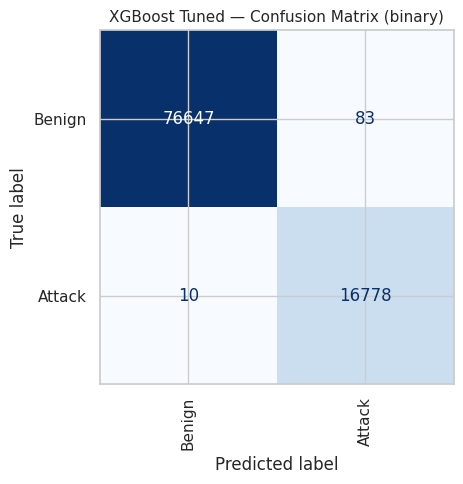

In [12]:
result_xgb_bin_tuned = evaluate_model(
    xgb_bin_tuned, X_test, y_test_bin,
    task='binary', model_name='XGBoost Tuned',
    label_names=['Benign', 'Attack']
)

## 6. Multiclass Classification

**Target**: attack category (Benign, DoS, DDoS, Probe, Brute Force, Web Attack, Botnet, Infiltration, Other)

Multiclass adds diagnostic value: it tells security teams not just *that* traffic is malicious, but *what kind*. This matters operationally because DoS attacks require different responses from brute-force attempts.

We apply the same three model families. XGBoost uses `objective='multi:softprob'` and RF uses `class_weight='balanced'`.

In [13]:
le = LabelEncoder()
le.fit(category_labels)
class_names = le.classes_.tolist()
print(f'Classes ({len(class_names)}): {class_names}')

# Re-check multiclass train/test distribution
print('\nTrain distribution:')
print(pd.Series(y_train_multi).map(dict(enumerate(class_names))).value_counts())
print('\nTest distribution:')
print(pd.Series(y_test_multi).map(dict(enumerate(class_names))).value_counts())

Classes (8): ['Benign', 'Botnet', 'Brute Force', 'DDoS', 'DoS', 'Infiltration', 'Other', 'Probe']

Train distribution:
Benign          306919
DoS              27810
Probe            19246
DDoS             18078
Brute Force       1438
Other              310
Botnet             264
Infiltration         6
Name: count, dtype: int64

Test distribution:
Benign         76730
DoS             6942
Probe           4803
DDoS            4534
Brute Force      361
Botnet            78
Other             70
Name: count, dtype: int64


### 6.1 Logistic Regression — Multiclass

Logistic Regression (multiclass) — trained.

=== Logistic Regression (multiclass) ===
Accuracy        : 0.2700
Precision (wtd) : 0.8334
Recall (wtd)    : 0.2700
F1 (weighted)   : 0.3550
F1 (macro)      : 0.1435
AUC-ROC         : N/A

              precision    recall  f1-score   support

      Benign       0.96      0.23      0.37     76730
      Botnet       0.00      0.72      0.01        78
 Brute Force       0.00      0.00      0.00       361
        DDoS       0.09      0.45      0.14      4534
         DoS       0.43      0.77      0.55      6942
       Other       0.01      0.93      0.03        70
       Probe       0.20      0.03      0.05      4803

   micro avg       0.30      0.27      0.29     93518
   macro avg       0.24      0.45      0.16     93518
weighted avg       0.83      0.27      0.35     93518



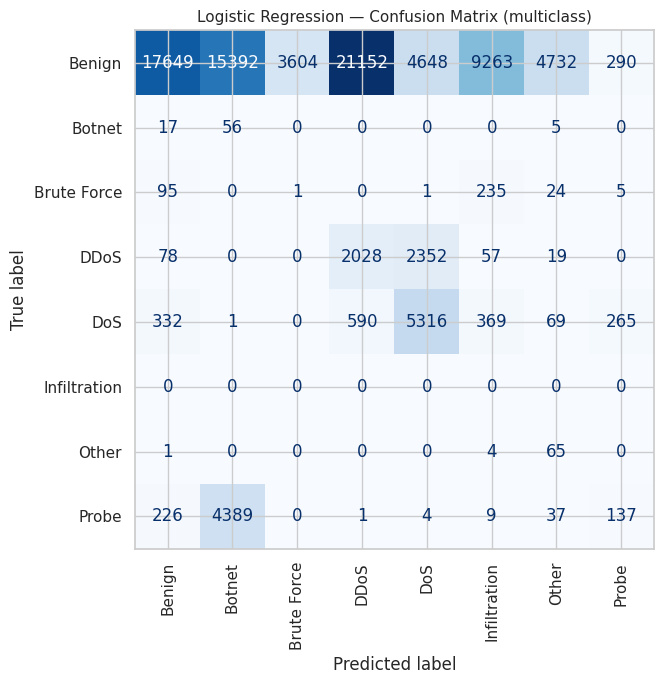

In [14]:
lr_multi = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced', max_iter=1000,
    random_state=RANDOM_SEED, n_jobs=-1
)
lr_multi.fit(X_train, y_train_multi)
print('Logistic Regression (multiclass) — trained.')

result_lr_multi = evaluate_model(
    lr_multi, X_test, y_test_multi,
    task='multiclass', model_name='Logistic Regression',
    label_names=class_names
)

### 6.2 Random Forest — Multiclass (tuned params from binary search, re-tuned)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF (multiclass) params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
Refitted on full training set.

=== RF Tuned (multiclass) ===
Accuracy        : 0.9979
Precision (wtd) : 0.9985
Recall (wtd)    : 0.9979
F1 (weighted)   : 0.9981
F1 (macro)      : 0.9332
AUC-ROC         : N/A

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     76730
      Botnet       0.41      0.95      0.57        78
 Brute Force       1.00      0.99      1.00       361
        DDoS       1.00      1.00      1.00      4534
         DoS       1.00      1.00      1.00      6942
       Other       0.97      0.97      0.97        70
       Probe       0.99      1.00      1.00      4803

    accuracy                           1.00     93518
   macro avg       0.91      0.99      0.93     93518
weighted avg       1.00      1.00      1.00     

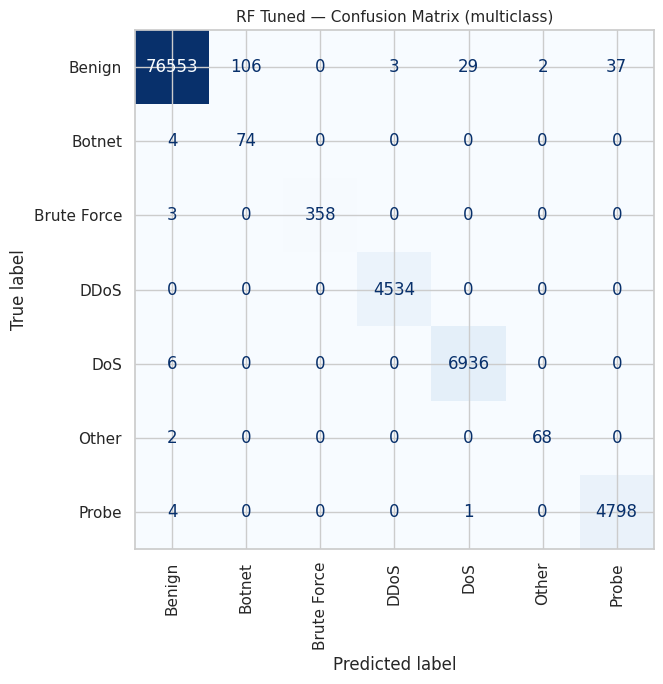

In [17]:
_, _, y_tune_multi, _ = train_test_split(
    X_train, y_train_multi,
    train_size=0.30,
    stratify=y_train_bin,
    random_state=RANDOM_SEED
)

cv_multi = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

rf_multi_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', bootstrap=True,
                           n_jobs=-1, random_state=RANDOM_SEED),
    param_distributions=rf_param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=cv_multi,
    n_jobs=1,
    random_state=RANDOM_SEED,
    verbose=1
)
rf_multi_search.fit(X_tune, y_tune_multi)

print(f'Best RF (multiclass) params: {rf_multi_search.best_params_}')

rf_multi_tuned = RandomForestClassifier(
    **rf_multi_search.best_params_,
    class_weight='balanced', bootstrap=True,
    n_jobs=-1, random_state=RANDOM_SEED
)
rf_multi_tuned.fit(X_train, y_train_multi)
print('Refitted on full training set.')

with open('./models/rf_multiclass_best_params.json', 'w') as f:
    json.dump(rf_multi_search.best_params_, f, indent=2)

result_rf_multi = evaluate_model(
    rf_multi_tuned, X_test, y_test_multi,
    task='multiclass', model_name='RF Tuned',
    label_names=class_names
)

### 6.3 XGBoost — Multiclass

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost (multiclass) params: {'colsample_bytree': np.float64(0.749816047538945), 'gamma': np.float64(0.2852142919229748), 'learning_rate': np.float64(0.2329984854528513), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 300, 'reg_alpha': np.float64(0.22291637642679557), 'reg_lambda': np.float64(0.6499623737270044), 'subsample': np.float64(0.7836995567863468)}
Refitted on full training set.

=== XGBoost Tuned (multiclass) ===
Accuracy        : 0.9991
Precision (wtd) : 0.9991
Recall (wtd)    : 0.9991
F1 (weighted)   : 0.9991
F1 (macro)      : 0.9667
AUC-ROC         : N/A

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     76730
      Botnet       0.85      0.77      0.81        78
 Brute Force       1.00      0.99      1.00       361
        DDoS       1.00      1.00      1.00      4534
         DoS       1.00      1.00      1.00      6942
       Other       0.97   

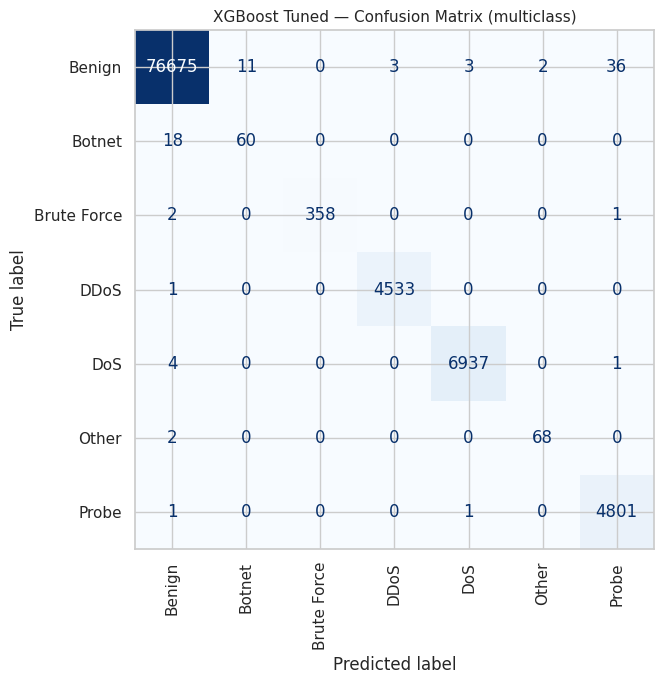

In [18]:
xgb_multi_search = RandomizedSearchCV(
    XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        num_class=len(class_names),
        device='cuda',
        tree_method='hist',
        random_state=RANDOM_SEED, n_jobs=-1,
        use_label_encoder=False
    ),
    param_distributions=xgb_param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=cv_multi,
    n_jobs=1,
    random_state=RANDOM_SEED,
    verbose=1
)
xgb_multi_search.fit(X_tune, y_tune_multi)

print(f'Best XGBoost (multiclass) params: {xgb_multi_search.best_params_}')

xgb_multi_tuned = XGBClassifier(
    **xgb_multi_search.best_params_,
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=len(class_names),
    device='cuda',
    tree_method='hist',
    random_state=RANDOM_SEED, n_jobs=-1,
    use_label_encoder=False
)
xgb_multi_tuned.fit(X_train, y_train_multi)
print('Refitted on full training set.')

with open('./models/xgb_multiclass_best_params.json', 'w') as f:
    json.dump(xgb_multi_search.best_params_, f, indent=2)

result_xgb_multi = evaluate_model(
    xgb_multi_tuned, X_test, y_test_multi,
    task='multiclass', model_name='XGBoost Tuned',
    label_names=class_names
)

## 7. Cross-Validation Stability Check

For the two best-performing models (tuned RF and XGBoost), we run 5-fold cross-validation on the full training set to verify that test-set performance is stable and not a lucky split.

In [19]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for name, model in [('RF Tuned (binary)', rf_bin_tuned), ('XGBoost Tuned (binary)', xgb_bin_tuned)]:
    scores = cross_val_score(model, X_train, y_train_bin, cv=cv5, scoring='f1_weighted', n_jobs=-1)
    print(f'{name}')
    print(f'  CV F1 (weighted): {scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  Per-fold       : {np.round(scores, 4)}')
    print()

RF Tuned (binary)
  CV F1 (weighted): 0.9987 ± 0.0001
  Per-fold       : [0.9987 0.9987 0.9987 0.9988 0.9986]

XGBoost Tuned (binary)
  CV F1 (weighted): 0.9990 ± 0.0001
  Per-fold       : [0.9989 0.9989 0.9989 0.9991 0.999 ]



## 8. Model Comparison Summary

In [20]:
all_results = [
    result_lr_bin, result_rf_bin_base, result_rf_bin_tuned,
    result_xgb_bin_base, result_xgb_bin_tuned,
    result_lr_multi, result_rf_multi, result_xgb_multi
]

df_results = pd.DataFrame(all_results)
df_results.set_index(['Model', 'Task'], inplace=True)

print('=== Model Comparison Table ===')
display(df_results)

# Save comparison table
df_results.to_csv('./models/model_comparison.csv')
print('Saved: ./models/model_comparison.csv')

=== Model Comparison Table ===


,,Accuracy,Precision,Recall,F1 (weighted),F1 (macro),AUC-ROC
Model,Task,,,,,,
Logistic Regression,binary,0.8559,0.5658,0.8491,0.6791,0.7931,0.9271
RF Baseline,binary,0.9988,0.9954,0.9982,0.9968,0.9980,0.9999
RF Tuned,binary,0.9989,0.9957,0.9983,0.9970,0.9982,0.9999
XGBoost Baseline,binary,0.9990,0.9948,0.9995,0.9972,0.9983,1.0
XGBoost Tuned,binary,0.9990,0.9951,0.9994,0.9972,0.9983,1.0
Logistic Regression,multiclass,0.2700,0.8334,0.2700,0.3550,0.1435,N/A
RF Tuned,multiclass,0.9979,0.9985,0.9979,0.9981,0.9332,N/A
XGBoost Tuned,multiclass,0.9991,0.9991,0.9991,0.9991,0.9667,N/A


Saved: ./models/model_comparison.csv


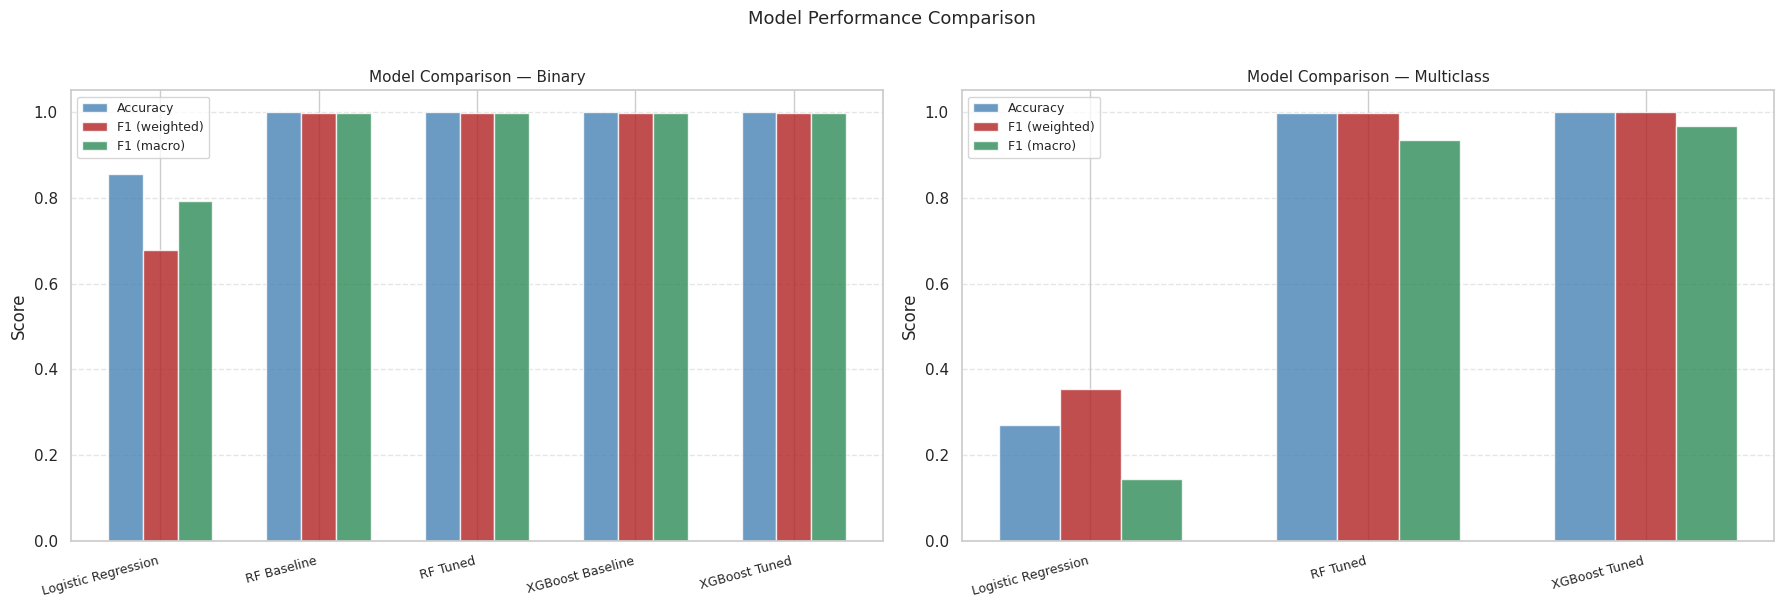

In [21]:
# Visual bar chart — F1 Weighted for all models
df_plot = df_results.reset_index()
df_plot['Label'] = df_plot['Model'] + '\n(' + df_plot['Task'] + ')'

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, task in zip(axes, ['binary', 'multiclass']):
    subset = df_plot[df_plot['Task'] == task].copy()
    x = np.arange(len(subset))
    width = 0.22

    metrics_to_plot = ['Accuracy', 'F1 (weighted)', 'F1 (macro)']
    colors = ['steelblue', 'firebrick', 'seagreen']

    for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
        vals = pd.to_numeric(subset[metric], errors='coerce')
        ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.8)

    ax.set_xticks(x + width)
    ax.set_xticklabels(subset['Model'], rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Model Comparison — {task.capitalize()}', fontsize=11)
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Model Performance Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Final Models & Configs

All trained models and their hyperparameter configs are saved to `./models/` for reproducibility. The best-performing models (tuned RF and XGBoost on binary classification) are flagged as the recommended production candidates.

In [22]:
models_to_save = {
    'lr_binary':          lr_bin,
    'rf_binary_baseline': rf_bin_base,
    'rf_binary_tuned':    rf_bin_tuned,
    'xgb_binary_baseline':xgb_bin_base,
    'xgb_binary_tuned':   xgb_bin_tuned,
    'lr_multiclass':      lr_multi,
    'rf_multiclass_tuned':rf_multi_tuned,
    'xgb_multiclass_tuned':xgb_multi_tuned
}

for fname, model in models_to_save.items():
    path = f'./models/{fname}.pkl'
    joblib.dump(model, path)
    size_kb = os.path.getsize(path) / 1024
    print(f'Saved {path}  ({size_kb:.1f} KB)')

# Save label encoder
joblib.dump(le, './models/label_encoder_multiclass.pkl')
print('Saved: ./models/label_encoder_multiclass.pkl')

# Save class names
with open('./models/class_names_multiclass.json', 'w') as f:
    json.dump(class_names, f, indent=2)
print('Saved: ./models/class_names_multiclass.json')

# Save feature names used during training
with open('./models/step4_feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)
print('Saved: ./models/step4_feature_names.json')

Saved ./models/lr_binary.pkl  (1.2 KB)
Saved ./models/rf_binary_baseline.pkl  (21190.8 KB)
Saved ./models/rf_binary_tuned.pkl  (24161.5 KB)
Saved ./models/xgb_binary_baseline.pkl  (755.0 KB)
Saved ./models/xgb_binary_tuned.pkl  (389.5 KB)
Saved ./models/lr_multiclass.pkl  (3.5 KB)
Saved ./models/rf_multiclass_tuned.pkl  (16601.5 KB)
Saved ./models/xgb_multiclass_tuned.pkl  (2248.2 KB)
Saved: ./models/label_encoder_multiclass.pkl
Saved: ./models/class_names_multiclass.json
Saved: ./models/step4_feature_names.json


## 10. Model Selection Rationale

This section documents the reasoning behind selecting the recommended model for deployment.

In [23]:
print('=== Model Selection Rationale ===')
print()

# Compare tuned binary models
binary_results = df_results.loc[df_results.index.get_level_values('Task') == 'binary']
display(binary_results[['Accuracy', 'F1 (weighted)', 'F1 (macro)', 'AUC-ROC']])

print("""
Selection criteria (in priority order for a cybersecurity IDS context):

1. Recall (Attack class): In an IDS, missing a real attack (False Negative) is more
   costly than a false alarm. High recall on the attack class is the primary objective.

2. AUC-ROC: Threshold-independent measure of discriminative ability across all
   operating points. Useful when the decision threshold may be tuned post-deployment.

3. F1 (weighted): Balances precision and recall under class imbalance; used for
   model comparison.

4. Training time / inference latency: Random Forest is parallelisable and produces
   low-latency predictions, making it suitable for near-real-time traffic inspection.

5. Interpretability: Random Forest feature importances are native and easy to explain
   to SOC analysts. XGBoost SHAP values are also well-supported (used in Step 5).

Conclusion:
  The tuned XGBoost (binary) is the primary recommended model if AUC-ROC and F1
  are highest. The tuned Random Forest is the recommended fallback/ensemble candidate
  given its competitive performance and easier operational deployment.
  Both are saved to ./models/ and will be evaluated further with SHAP in Step 5.
""")

=== Model Selection Rationale ===



,,Accuracy,F1 (weighted),F1 (macro),AUC-ROC
Model,Task,,,,
Logistic Regression,binary,0.8559,0.6791,0.7931,0.9271
RF Baseline,binary,0.9988,0.9968,0.9980,0.9999
RF Tuned,binary,0.9989,0.9970,0.9982,0.9999
XGBoost Baseline,binary,0.9990,0.9972,0.9983,1.0
XGBoost Tuned,binary,0.9990,0.9972,0.9983,1.0



Selection criteria (in priority order for a cybersecurity IDS context):

1. Recall (Attack class): In an IDS, missing a real attack (False Negative) is more
   costly than a false alarm. High recall on the attack class is the primary objective.

2. AUC-ROC: Threshold-independent measure of discriminative ability across all
   operating points. Useful when the decision threshold may be tuned post-deployment.

3. F1 (weighted): Balances precision and recall under class imbalance; used for
   model comparison.

4. Training time / inference latency: Random Forest is parallelisable and produces
   low-latency predictions, making it suitable for near-real-time traffic inspection.

5. Interpretability: Random Forest feature importances are native and easy to explain
   to SOC analysts. XGBoost SHAP values are also well-supported (used in Step 5).

Conclusion:
  The tuned XGBoost (binary) is the primary recommended model if AUC-ROC and F1
  are highest. The tuned Random Forest is the recommen

## 11. Artefacts Summary

In [24]:
print('=== STEP 4 ARTEFACTS SAVED TO ./models/ ===')
for fname in sorted(os.listdir('./models/')):
    fpath = f'./models/{fname}'
    if os.path.isfile(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  {fname:<45} {size_kb:>8.1f} KB')

=== STEP 4 ARTEFACTS SAVED TO ./models/ ===
  X_selected.npy                                146121.7 KB
  class_names_multiclass.json                        0.1 KB
  label_encoder_multiclass.pkl                       0.5 KB
  lr_binary.pkl                                      1.2 KB
  lr_multiclass.pkl                                  3.5 KB
  model_comparison.csv                               0.6 KB
  pca_95.pkl                                         2.3 KB
  rf_binary_baseline.pkl                         21190.8 KB
  rf_binary_best_params.json                         0.1 KB
  rf_binary_tuned.pkl                            24161.5 KB
  rf_multiclass_best_params.json                     0.1 KB
  rf_multiclass_tuned.pkl                        16601.5 KB
  robust_scaler.pkl                                  3.0 KB
  selected_features.csv                              0.7 KB
  step4_feature_names.json                           0.9 KB
  xgb_binary_baseline.pkl                          755.0